In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json
from collections import Counter

I0000 00:00:1781726377.597309 1773795 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [4]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [8]:
# Normalize the images
all_images = []
all_labels = []

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["label"] == "NonCancer" :
        all_labels.append(0)
    elif meta["label"] == "Unknown" :
        continue
    elif meta["label"] == "IndexCancer" or meta["label"] == "PreIndexCancer" : 
        all_labels.append(1)
    else : 
        continue
    img = np.load(ID)['data']
    img = img.astype("float32") / 255.0 # Normalize to 0-1
    img = np.expand_dims(img, axis=-1)
    all_images.append(img)

In [15]:
print(f"{len(all_images)} {len(all_labels)}")
all_labels = np.array(all_labels, dtype=np.float32)
print(Counter(all_labels.astype(int)))

14702 14702
Counter({np.int64(0): 7351, np.int64(1): 7351})


In [17]:
# Create balanced dataset
nc_images = []
nc_labels = []
c_images = []
c_labels = []
NonCancer = 0
Cancer = 0
for img, label in zip(all_images, all_labels) :
    if NonCancer == 7351 and Cancer == 7351 :
        break
    if NonCancer < 7351 and label == 0 :
        nc_images.append(img)
        nc_labels.append(label)
        NonCancer += 1
    elif Cancer < 7351 and label == 1 :
        c_images.append(img)
        c_labels.append(label)
        Cancer += 1
nc_images = np.array(nc_images, dtype=np.float32)
nc_labels = np.array(nc_labels, dtype=np.float32)
c_images = np.array(c_images, dtype=np.float32)
c_labels = np.array(c_labels, dtype=np.float32)

print(Counter(nc_labels.astype(int)))
print(Counter(c_labels.astype(int)))

Counter({np.int64(0): 7351})
Counter({np.int64(1): 7351})


In [25]:
# Split data

train_size = int(0.7 * len(nc_images)) 
val_size = int(0.15 * len(nc_images))
test_size = int(0.15 * len(nc_images))

train_images = np.concatenate([nc_images[:train_size], c_images[:train_size]], axis=0)
val_images = np.concatenate([nc_images[train_size:val_size + train_size], c_images[train_size:val_size + train_size]], axis=0)
test_images = np.concatenate([nc_images[val_size + train_size:val_size + train_size + test_size], c_images[val_size + train_size:val_size + train_size + test_size]], axis=0)

train_labels = np.concatenate([nc_labels[:train_size], c_labels[:train_size]], axis=0)
val_labels = np.concatenate([nc_labels[train_size:val_size + train_size], c_labels[train_size:val_size + train_size]], axis=0)
test_labels = np.concatenate([nc_labels[val_size + train_size:val_size + train_size + test_size], c_labels[val_size + train_size:val_size + train_size + test_size]], axis=0)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")


Train: 10290, Val: 2204, Test: 2204
Train: 10290, Val: 2204, Test: 2204


In [26]:
print("train", Counter(train_labels.astype(int)))
print("val", Counter(val_labels.astype(int)))
print("test", Counter(test_labels.astype(int)))

train Counter({np.int64(0): 5145, np.int64(1): 5145})
val Counter({np.int64(0): 1102, np.int64(1): 1102})
test Counter({np.int64(0): 1102, np.int64(1): 1102})


In [27]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.5000
Average class probability in validation set: 0.5000
Average class probability in test set:       0.5000


In [28]:
# Check dimension size and color channel
print("Shape:", all_images[0].shape)

Shape: (256, 256, 1)


In [29]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.shuffle(len(train_labels)).batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.shuffle(len(train_labels)).batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.shuffle(len(train_labels)).batch(32)

I0000 00:00:1781729199.612524 1773795 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:bd:00.0, compute capability: 8.0


In [30]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [31]:
# Import pretrained model
base_model = tf.keras.applications.EfficientNetB0(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [32]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [33]:
# Convert image tensor from 1 channel to 3 for the model
inputs = tf.keras.Input(shape=(256, 256, 1))
x = tf.keras.layers.Lambda(tf.image.grayscale_to_rgb)(inputs)

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # ← add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs, outputs) # wrap all layers

In [34]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [37]:
initial_epochs = 10
history = model.fit(train_ds, epochs=initial_epochs, validation_data = val_ds)

Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.4866 - binary_accuracy: 0.4909 - loss: 0.7004 - recall: 0.5046 - val_auc_pr: 0.5000 - val_binary_accuracy: 0.5000 - val_loss: 0.6936 - val_recall: 1.0000
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.5014 - binary_accuracy: 0.4975 - loss: 0.6974 - recall: 0.4871 - val_auc_pr: 0.5000 - val_binary_accuracy: 0.5000 - val_loss: 0.6936 - val_recall: 1.0000
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.4990 - binary_accuracy: 0.5002 - loss: 0.6972 - recall: 0.5090 - val_auc_pr: 0.5000 - val_binary_accuracy: 0.5000 - val_loss: 0.6947 - val_recall: 0.0000e+00
Epoch 4/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - auc_pr: 0.5022 - binary_accuracy: 0.4998 - loss: 0.6981 - recall: 0.5081 - val_auc_pr: 0.5000 - val_binary_accuracy: 0.5000 - val_loss: 0.7064 - val_recall: 0.0000e+00
Epoch 5/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.4970 - binary_accuracy: 0.4954 - loss: 0.6968 - rec

In [38]:
# Unfreeze base model for fine tunning
base_model.trainable = True

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 2,564 (10.02 KB)

In [39]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.0),
    ],
)

In [40]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history = model.fit(train_ds, epochs=total_epochs, validation_data = val_ds)

Epoch 1/20


W0000 00:00:1781729584.754646 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781729584.755829 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
E0000 00:00:1781729592.288575 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729599.018763 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729608.623556 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729613.349197 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub

321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - binary_accuracy: 0.5011 - loss: 0.6722

W0000 00:00:1781729676.073280 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781729676.073736 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
E0000 00:00:1781729699.736012 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729700.774738 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729701.740294 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781729703.263627 1812101 cuda_timer.cc:87] Delay kernel timed out: measured time has sub

322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - binary_accuracy: 0.5011 - loss: 0.6721

W0000 00:00:1781729753.687634 1812102 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781729753.688909 1812102 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
W0000 00:00:1781729757.768865 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781729757.769077 1812101 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


322/322 ━━━━━━━━━━━━━━━━━━━━ 200s 307ms/step - binary_accuracy: 0.5000 - loss: 0.6531 - val_binary_accuracy: 0.5000 - val_loss: 0.7037
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - binary_accuracy: 0.5000 - loss: 0.5903 - val_binary_accuracy: 0.4923 - val_loss: 18.9935
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - binary_accuracy: 0.5000 - loss: 0.5435 - val_binary_accuracy: 0.5000 - val_loss: 1.3044
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - binary_accuracy: 0.5000 - loss: 0.4815 - val_binary_accuracy: 0.5000 - val_loss: 0.7724
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - binary_accuracy: 0.5000 - loss: 0.4177 - val_binary_accuracy: 0.4896 - val_loss: 65.7405
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - binary_accuracy: 0.5000 - loss: 0.3519 - val_binary_accuracy: 0.5000 - val_loss: 1.0812
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - binary_accuracy: 0.5000 - loss: 0.2690 - val_binary_accuracy: 0.5000 - val_loss: 0.8062

In [41]:
predictions = model.predict(test_ds)

68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

W0000 00:00:1781730023.013619 1812102 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781730023.014878 1812102 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step


In [42]:
predictions

array([[0.00181435],
       [0.17578743],
       [0.9701016 ],
       ...,
       [0.00113555],
       [0.4507173 ],
       [0.03123507]], shape=(2204, 1), dtype=float32)

In [43]:
print(model.evaluate(x=test_ds))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - binary_accuracy: 0.5000 - loss: 1.1845
[1.1844943761825562, 0.5]


69/69 - 1s - 12ms/step - binary_accuracy: 0.5000 - loss: 1.1845


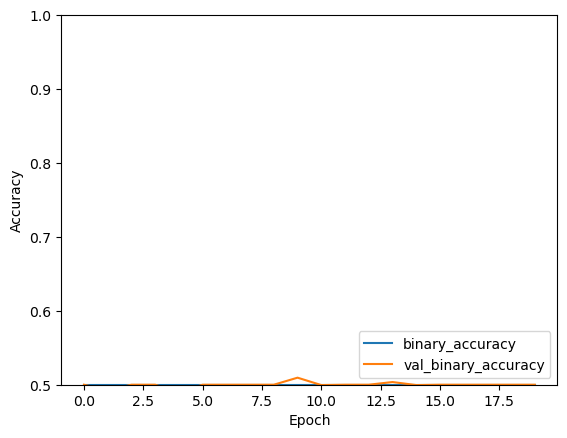

In [44]:
# Evaluate model
plt.plot(history.history['binary_accuracy'], label='binary_accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_binary_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)